# Week 4 — Monday: Harris & FAST Corner Detection

## Learning Objectives
- Understand corner detection theory (Harris, Shi-Tomasi)
- Learn FAST detector for speed
- Implement Harris from scratch
- Compare detectors on real images
- Build a keypoint visualizer

## Key Concepts
1. **Harris Corner Detector**: Eigenvalue-based corner response
2. **Shi-Tomasi**: Improved Harris response
3. **FAST**: Faster and simpler corner detection
4. **Non-maximum suppression**: Peak filtering for keypoints
5. **Scale-space analysis**: Multi-scale keypoint detection

## Section 1: Harris Corner Detector Theory

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

plt.rcParams['figure.figsize'] = (12, 6)

### 1.1 Harris Corner Response

**Core Idea**: A corner has large intensity changes in all directions

**Mathematical Foundation**:

For each pixel, compute the structure tensor (auto-correlation matrix):
$$M = \begin{pmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{pmatrix}$$

Where $I_x, I_y$ are image gradients

**Harris Response**:
$$R = \det(M) - k \cdot \text{trace}(M)^2$$

- $\det(M) = \lambda_1 \lambda_2$ (product of eigenvalues)
- $\text{trace}(M) = \lambda_1 + \lambda_2$ (sum of eigenvalues)
- $k$ = Harris parameter (typically 0.04-0.06)

**Interpretation**:
- Flat region: Both $\lambda$ small → $R$ small
- Edge: One $\lambda$ large → $R$ negative
- Corner: Both $\lambda$ large → $R$ large positive

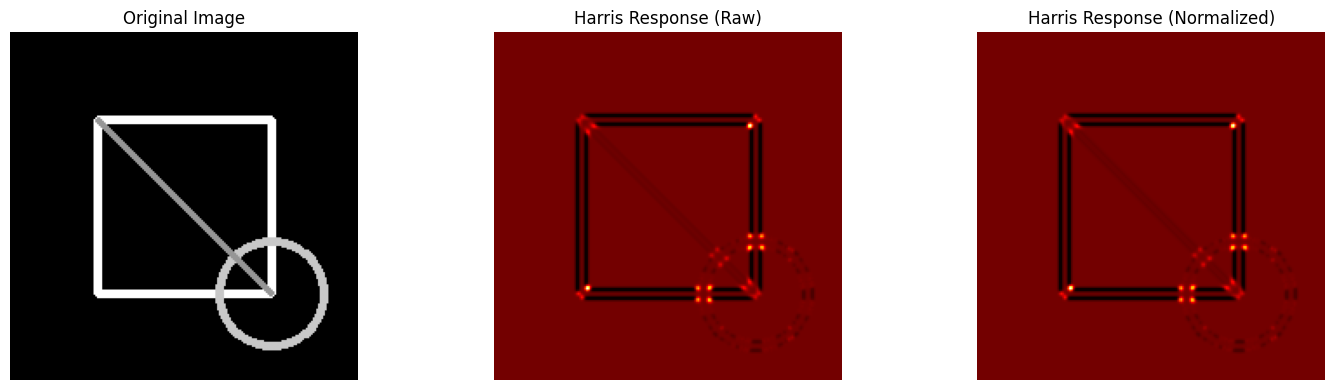

Harris response range: [-14561571840.00, 77099687936.00]
Positive values (potential corners): 1838 pixels


In [6]:
def harris_detector_manual(image, k=0.04, window_size=5):
    """
    Manual implementation of Harris corner detector.
    
    Args:
        image: Grayscale image
        k: Harris parameter
        window_size: Neighborhood size for structure tensor
    
    Returns:
        harris_response: Corner response map
    """
    # Compute image gradients
    Ix = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
    Iy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
    
    # Compute products of gradients
    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy
    
    # Gaussian smoothing for structure tensor
    sigma = window_size / 6
    Sx2 = cv2.GaussianBlur(Ix2, (window_size, window_size), sigma)
    Sy2 = cv2.GaussianBlur(Iy2, (window_size, window_size), sigma)
    Sxy = cv2.GaussianBlur(Ixy, (window_size, window_size), sigma)
    
    # Harris response
    # R = det(M) - k * trace(M)^2
    det_M = Sx2 * Sy2 - Sxy ** 2
    trace_M = Sx2 + Sy2
    harris_response = det_M - k * (trace_M ** 2)
    
    return harris_response

# Test with a simple pattern image
test_img = np.zeros((200, 200), dtype=np.uint8)
# Corner patterns
cv2.rectangle(test_img, (50, 50), (150, 150), 255, 3)  # Square with corners
cv2.circle(test_img, (150, 150), 30, 200, 3)  # Circle
cv2.line(test_img, (50, 50), (150, 150), 150, 2)  # Diagonal line

# Compute Harris response
harris_resp = harris_detector_manual(test_img, k=0.04, window_size=7)

# Normalize for visualization
harris_norm = cv2.normalize(harris_resp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(harris_resp, cmap='hot')
axes[1].set_title('Harris Response (Raw)')
axes[1].axis('off')

axes[2].imshow(harris_norm, cmap='hot')
axes[2].set_title('Harris Response (Normalized)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print(f"Harris response range: [{harris_resp.min():.2f}, {harris_resp.max():.2f}]")
print(f"Positive values (potential corners): {np.sum(harris_resp > 0)} pixels")

## Section 2: OpenCV Harris Corner Detection

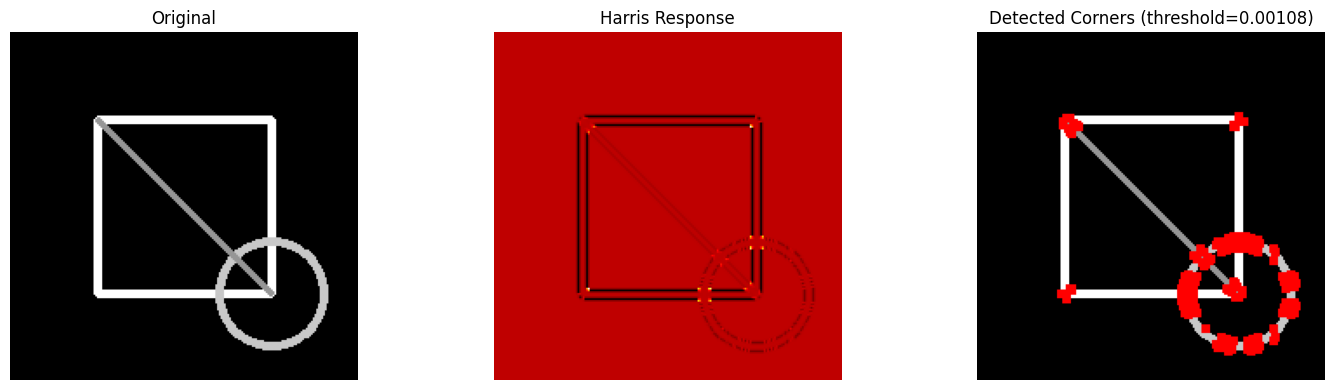

Number of corners detected: 1948


In [7]:
# Use OpenCV's built-in Harris detector
harris_cv = cv2.cornerHarris(test_img, blockSize=2, ksize=3, k=0.04)

# Dilate for visualization
harris_dilated = cv2.dilate(harris_cv, None, iterations=2)

# Threshold to get corner points
threshold = 0.01 * harris_cv.max()
corners = np.where(harris_dilated > threshold)

# Draw corners
marked_img = cv2.cvtColor(test_img, cv2.COLOR_GRAY2BGR)
marked_img[harris_dilated > threshold] = [0, 0, 255]  # Red

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(harris_cv, cmap='hot')
axes[1].set_title('Harris Response')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(marked_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Detected Corners (threshold={threshold:.5f})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print(f"Number of corners detected: {len(corners[0])}")

## Section 3: Shi-Tomasi Detector

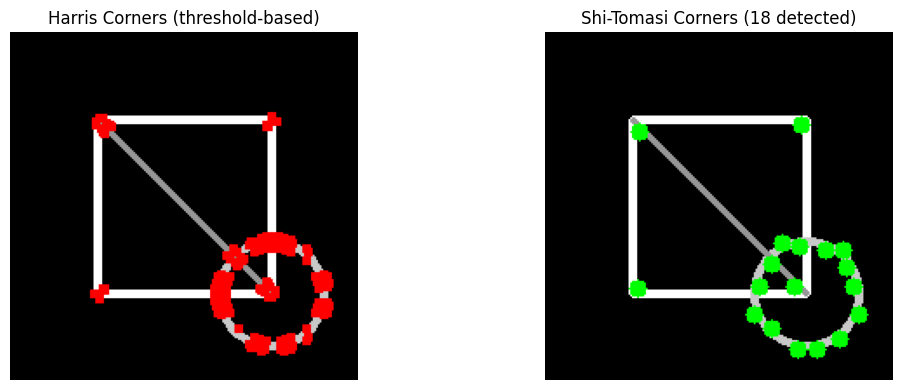

In [9]:
# Shi-Tomasi uses min eigenvalue instead of Harris response
# R = min(λ₁, λ₂) - more intuitive than Harris formula

corners_st = cv2.goodFeaturesToTrack(
    test_img,
    maxCorners=100,
    qualityLevel=0.01,
    minDistance=10,
    useHarrisDetector=False  # Shi-Tomasi
)

# Convert to integer coordinates
if corners_st is not None:
    corners_st = np.int32(corners_st)

# Draw Shi-Tomasi corners
st_img = cv2.cvtColor(test_img, cv2.COLOR_GRAY2BGR)
if corners_st is not None:
    for corner in corners_st:
        x, y = corner.ravel()
        cv2.circle(st_img, (x, y), 5, (0, 255, 0), -1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(marked_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Harris Corners (threshold-based)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(st_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Shi-Tomasi Corners ({len(corners_st) if corners_st is not None else 0} detected)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Section 4: FAST Detector

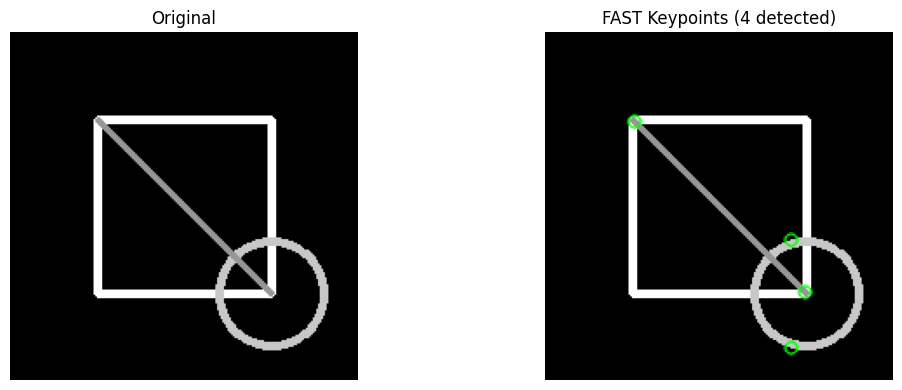


FAST Keypoints: 4
  Keypoint size range: [7.00, 7.00]
  Response range: [104.00, 199.00]


In [10]:
# FAST (Features from Accelerated Segment Test)
# Much faster than Harris, uses simple pixel comparisons

# Initialize FAST detector
fast = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)

# Detect keypoints
keypoints_fast = fast.detect(test_img, None)

# Draw keypoints
fast_img = cv2.drawKeypoints(test_img, keypoints_fast, None, 
                             color=(0, 255, 0),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(fast_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'FAST Keypoints ({len(keypoints_fast)} detected)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"\nFAST Keypoints: {len(keypoints_fast)}")
if len(keypoints_fast) > 0:
    sizes = [kp.size for kp in keypoints_fast]
    responses = [kp.response for kp in keypoints_fast]
    print(f"  Keypoint size range: [{min(sizes):.2f}, {max(sizes):.2f}]")
    print(f"  Response range: [{min(responses):.2f}, {max(responses):.2f}]")

## Section 5: Comparison & Performance

In [11]:
import time

# Load a larger test image
large_img = cv2.imread('test_image.jpg', cv2.IMREAD_GRAYSCALE) if False else cv2.resize(test_img, (600, 600))

# Test different methods
methods = [
    ('Harris (manual)', lambda img: harris_detector_manual(img, k=0.04, window_size=7)),
    ('Harris (OpenCV)', lambda img: cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)),
    ('Shi-Tomasi', lambda img: cv2.goodFeaturesToTrack(img, 100, 0.01, 10, useHarrisDetector=False)),
    ('FAST', lambda img: fast.detect(img, None))
]

print("\nPerformance Comparison on 600x600 image:")
print("-" * 60)
print(f"{'Method':<20} {'Keypoints':<15} {'Time (ms)':<15}")
print("-" * 60)

for name, method in methods:
    start = time.time()
    result = method(large_img)
    elapsed = (time.time() - start) * 1000
    
    if isinstance(result, list):
        count = len(result)
    else:
        count = "N/A"
    
    print(f"{name:<20} {str(count):<15} {elapsed:<15.3f}")


Performance Comparison on 600x600 image:
------------------------------------------------------------
Method               Keypoints       Time (ms)      
------------------------------------------------------------
Harris (manual)      N/A             22.840         
Harris (OpenCV)      N/A             22.116         
Shi-Tomasi           N/A             20.109         
FAST                 N/A             0.823          


## Section 6: Multi-scale Corner Detection

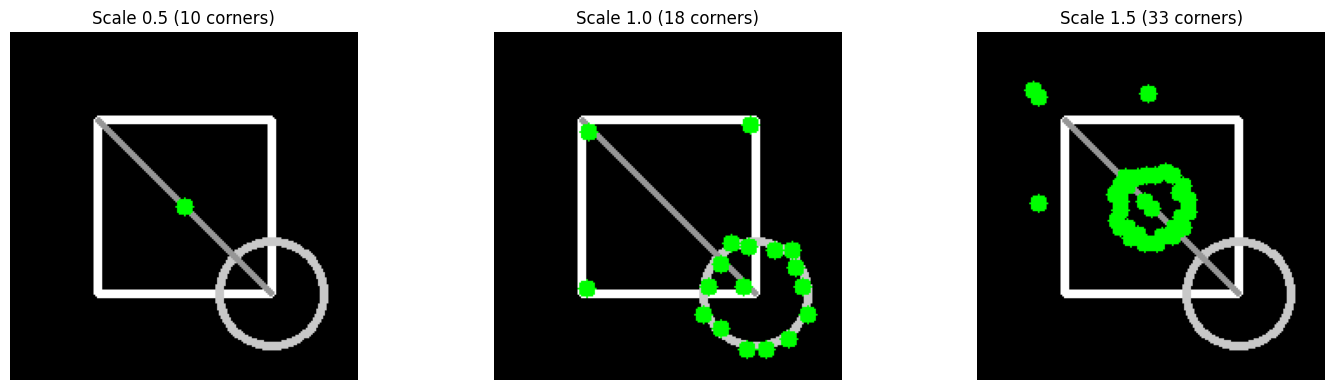


Total keypoints across scales: 61


In [12]:
# Multi-scale: Detect corners at different scales
scales = [0.5, 1.0, 1.5]
fig, axes = plt.subplots(1, len(scales), figsize=(15, 4))

all_keypoints = []

for i, scale in enumerate(scales):
    # Resize image
    h, w = test_img.shape
    scaled_img = cv2.resize(test_img, (int(w*scale), int(h*scale)))
    
    # Detect corners
    corners_st = cv2.goodFeaturesToTrack(scaled_img, 100, 0.01, 10, useHarrisDetector=False)
    
    # Scale back
    if corners_st is not None:
        corners_st[:, 0, :] /= scale
        all_keypoints.extend(corners_st.reshape(-1, 2))
    
    # Draw
    marked = cv2.cvtColor(test_img, cv2.COLOR_GRAY2BGR)
    if corners_st is not None:
        for corner in corners_st:
            x, y = corner.ravel() / scale
            cv2.circle(marked, (int(x), int(y)), 5, (0, 255, 0), -1)
    
    axes[i].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Scale {scale} ({len(corners_st) if corners_st is not None else 0} corners)')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal keypoints across scales: {len(all_keypoints)}")

## Section 7: Key Takeaways

1. **Harris**: Eigenvalue-based, robust, moderate speed
2. **Shi-Tomasi**: Improved Harris, uses min eigenvalue
3. **FAST**: Very fast, simple pixel tests, good for real-time
4. **Trade-off**: Accuracy vs Speed (Harris > Shi-Tomasi > FAST)
5. **Parameters**: Threshold, window size affect detection quality
6. **Non-max suppression**: Remove duplicate nearby keypoints
7. **Multi-scale**: Detect at different scales for robustness

## Exercises

1. Implement non-maximum suppression from scratch.
2. Compare corner detectors on rotated versions of the same image.
3. Analyze how threshold affects the number and quality of detected corners.
4. Implement Harris detector with different k values and compare results.